2026-07-17 10:45:43,923 - INFO - Successfully loaded ../data/raw/Fraud_Data.csv with shape (151112, 11)
2026-07-17 10:45:44,002 - INFO - Successfully loaded ../data/raw/IpAddress_to_Country.csv with shape (138846, 3)



 Data Cleaning
Fraud_Data: Dropped 0 duplicates.


2026-07-17 10:45:44,642 - INFO - Range-based IP lookup complete successfully with matching float64 types.
2026-07-17 10:45:44,862 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



 Exploratory Data Analysis

Fraud_Data Imbalance:
  Legit: 136961 (90.635%)
  Fraud: 14151 (9.365%)

CreditCard Imbalance:
  Legit: 283253 (99.833%)
  Fraud: 473 (0.167%)


2026-07-17 10:45:44,947 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


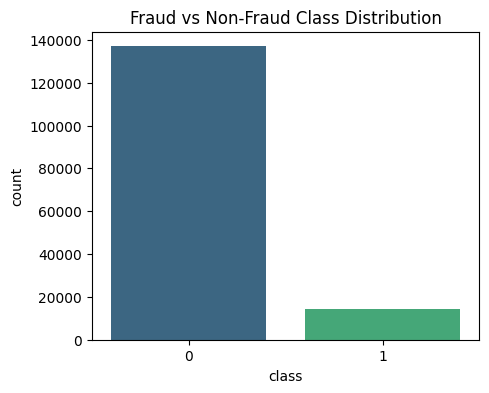

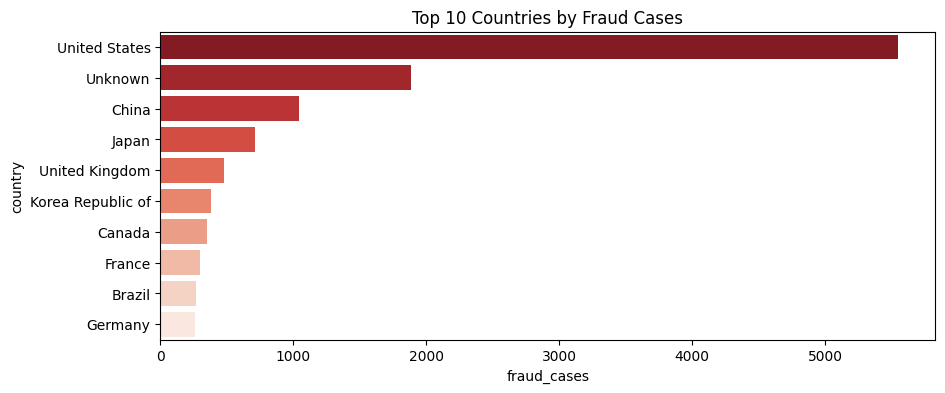

Saved intermediate features successfully!


In [9]:
# ==========================================
# 1. CLEANING, TYPE CORRECTION & MERGE (Fraud_Data)
# ==========================================
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('../')
from src.processing import load_data, ip_to_int, merge_ip_range

# Load both datasets
fraud_df = load_data('../data/raw/Fraud_Data.csv')
ip_df = load_data('../data/raw/IpAddress_to_Country.csv')

print(f"\n Data Cleaning")
# --- Clean Fraud_Data.csv ---
# Correct Data Types
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Duplicates
dup_count_f = fraud_df.duplicated().sum()
fraud_df = fraud_df.drop_duplicates()
print(f"Fraud_Data: Dropped {dup_count_f} duplicates.")

# IP conversion & Merge
fraud_df['ip_address_int'] = fraud_df['ip_address'].apply(ip_to_int)
fraud_df = fraud_df.dropna(subset=['ip_address_int'])
fraud_df['ip_address_int'] = fraud_df['ip_address_int'].astype(np.int64)

df_geo = merge_ip_range(fraud_df, ip_df)

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (Both Datasets)
# ==========================================
# Class Imbalance Quantification

print(f"\n Exploratory Data Analysis")

for name, df, col in [("Fraud_Data", df_geo, 'class'), ("CreditCard", credit_df, 'Class')]:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    print(f"\n{name} Imbalance:\n  Legit: {counts[0]} ({pcts[0]:.3f}%)\n  Fraud: {counts[1]} ({pcts[1]:.3f}%)")

# Country-level Fraud Analysis (Fraud_Data)
country_fraud = df_geo.groupby('country')['class'].agg(['count', 'sum']).rename(columns={'sum': 'fraud_cases'})
country_fraud['fraud_rate'] = country_fraud['fraud_cases'] / country_fraud['count']
top_fraud_countries = country_fraud.sort_values(by='fraud_cases', ascending=False).head(10)

# Plot Class Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='class', data=df_geo, hue='class', palette='viridis', legend=False)
plt.title('Fraud vs Non-Fraud Class Distribution')
plt.show()

# Analyze Fraud Patterns by Country (Top 10 Countries with highest fraud count)
plt.figure(figsize=(10,4))
sns.barplot(x=top_fraud_countries['fraud_cases'], y=top_fraud_countries.index, hue=top_fraud_countries.index, palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Fraud Cases')
plt.show()

# ==========================================
# 3. FEATURE ENGINEERING (Fraud_Data.csv)
# ==========================================
# Time Features
df_geo['hour_of_day'] = df_geo['purchase_time'].dt.hour
df_geo['day_of_week'] = df_geo['purchase_time'].dt.dayofweek
df_geo['time_since_signup'] = (df_geo['purchase_time'] - df_geo['signup_time']).dt.total_seconds() / 60.0 # minutes

# Transaction Velocity (Count of occurrences of device and IP)
df_geo['device_velocity'] = df_geo.groupby('device_id')['user_id'].transform('count')
df_geo['ip_velocity'] = df_geo.groupby('ip_address')['user_id'].transform('count')

# Clean final columns
features_fraud = df_geo.drop(columns=['user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address', 'ip_address_int', 'lower_bound_ip_address', 'upper_bound_ip_address'])

# Save the intermediate feature-engineered dataset to disk
features_fraud.to_csv('../data/processed/intermediate_features_fraud.csv', index=False)
print("Saved intermediate features successfully!")